##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise

In [1]:
!pip install keras-cv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 46.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import tensorflow as tf
from PIL import Image
import keras_cv
import matplotlib.pyplot as plt

In [3]:
# Load pretrained YOLOV8 model with Pascal VOC preset
yolo = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

In [4]:
image_paths = [
    "/content/image1.webp",
    "/content/image2.webp",
    "/content/image3.webp",
    "/content/image4.avif",
    "/content/image5.avif"
]

images = [np.array(Image.open(path).convert("RGB")) for path in image_paths]

In [5]:
# Resize images for inference
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

images_resized = np.array([inference_resizing(img) for img in images])

In [6]:
# Run object detection
predictions = yolo.predict(images_resized, verbose=0)

In [7]:
# Pascal VOC class names
voc_classes = {
    0: "aeroplane", 1: "bicycle", 2: "bird", 3: "boat", 4: "bottle",
    5: "bus", 6: "car", 7: "cat", 8: "chair", 9: "cow",
    10: "diningtable", 11: "dog", 12: "horse", 13: "motorbike",
    14: "person", 15: "pottedplant", 16: "sheep", 17: "sofa",
    18: "train", 19: "tvmonitor"
}

# Print detected labels and confidence scores
for i in range(len(predictions["confidence"])):
    print(f"\nImage {i+1}: {image_paths[i]}")
    valid = predictions["confidence"][i] > 0
    confs = predictions["confidence"][i][valid]
    clss = predictions["classes"][i][valid].astype(int)

    if len(confs) == 0:
        print("No objects detected")
    else:
        for c, k in zip(confs, clss):
            print(f"Detected: {voc_classes[k]} | Confidence: {float(c):.3f}")


Image 1: /content/image1.webp
Detected: car | Confidence: 0.980

Image 2: /content/image2.webp
Detected: bus | Confidence: 0.982

Image 3: /content/image3.webp
Detected: horse | Confidence: 0.985

Image 4: /content/image4.avif
Detected: chair | Confidence: 0.802
Detected: diningtable | Confidence: 0.572

Image 5: /content/image5.avif
Detected: dog | Confidence: 0.991


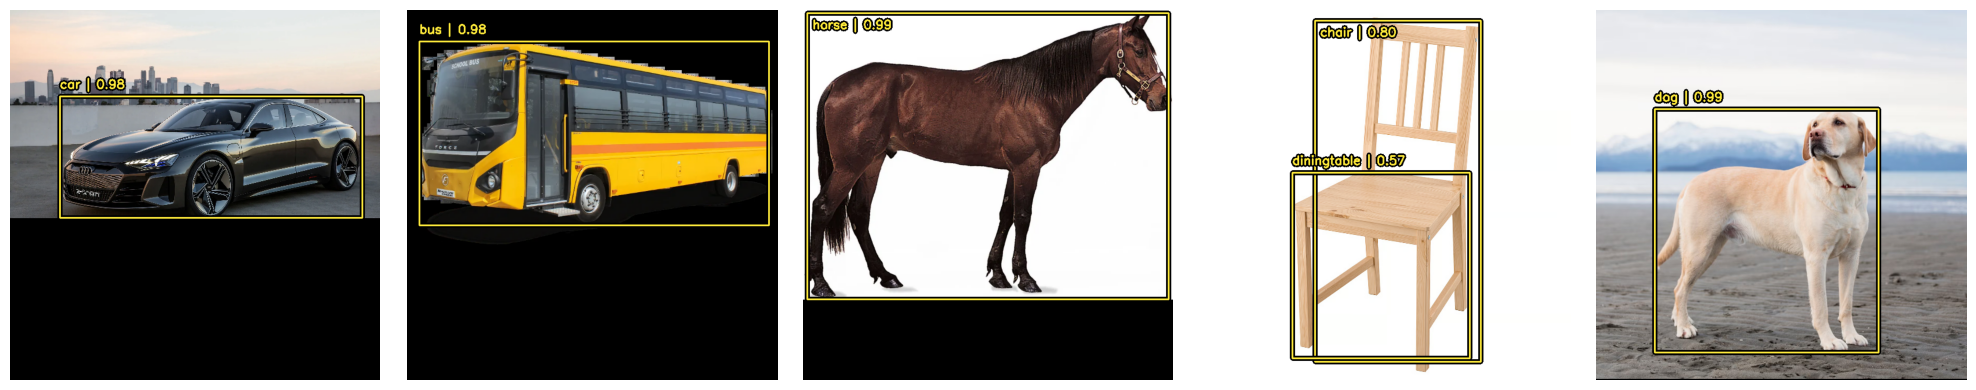

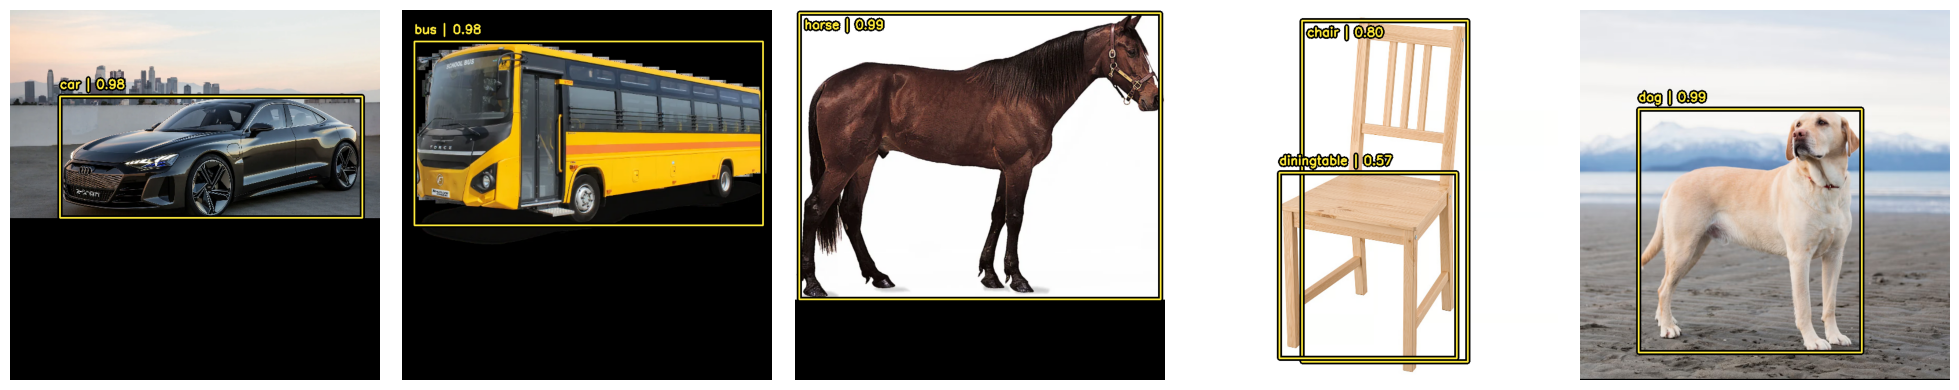

In [8]:
# Visualize predictions
keras_cv.visualization.plot_bounding_box_gallery(
    images_resized,
    value_range=(0, 255),
    rows=1,
    cols=5,
    y_pred=predictions,
    class_mapping=voc_classes,
    scale=4,
    font_scale=0.7,
    bounding_box_format="xywh"
)

Image 1 – image1.webp

Detected object: car

Confidence score: 0.980

Correct detection: Yes

Missed / Incorrect objects: None

The model successfully detected the car with a high confidence score.

Image 2 – image2.webp

Detected object: bus

Confidence score: 0.982

Correct detection: Yes

Missed / Incorrect objects: None

The bus was correctly detected with very high confidence.

Image 3 – image3.webp

Detected object: horse

Confidence score: 0.985

Correct detection: Yes

Missed / Incorrect objects: None

The model correctly detected the horse in the image.

Image 4 – image4.avif

Detected objects: chair, diningtable

Confidence scores:

chair: 0.802

diningtable: 0.572

Correct detection: chair

Incorrect / extra detection: diningtable

The chair was correctly detected, but the model also detected a dining table, which may be an incorrect or extra detection depending on the scene.

Image 5 – image5.avif

Detected object: dog

Confidence score: 0.991

Correct detection: Yes

Missed / Incorrect objects: None

The dog was correctly detected with a very high confidence score.



The YOLOv8 model correctly detected the main object in all five images. Most detections have very high confidence scores (above 0.98). One image produced an extra detection (diningtable), which shows that object detection models may sometimes produce additional labels when objects have similar visual features.